# Gerando gráfico de quantidade

In [ ]:
! pip install requests matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


16:23:46 | Total usuários: 14


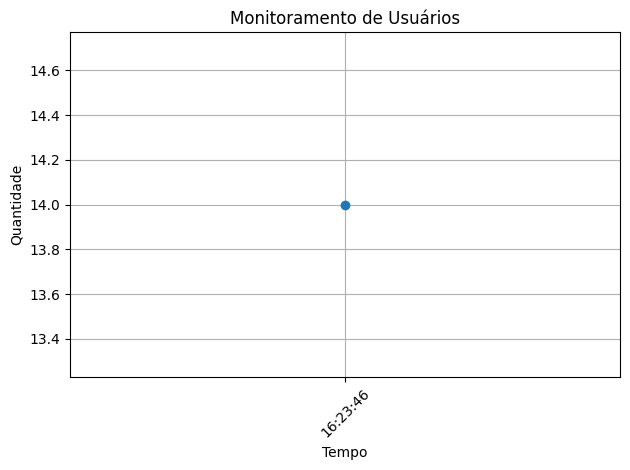

16:24:47 | Total usuários: 11


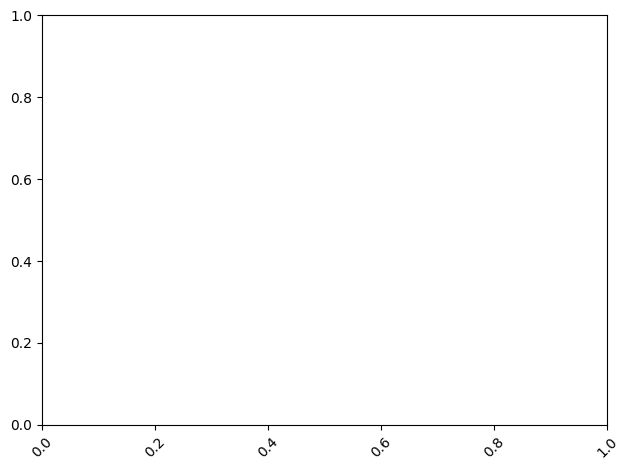

16:25:48 | Total usuários: 4


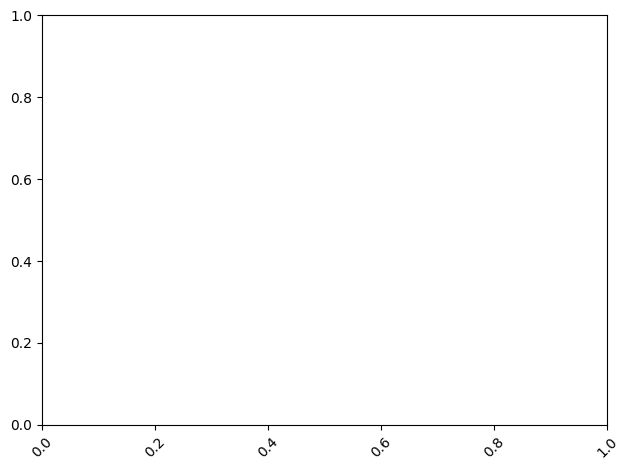

KeyboardInterrupt: 

In [3]:
import time
import requests
import matplotlib.pyplot as plt
from datetime import datetime
import csv
import os

URL = "https://serverest.dev/usuarios"
INTERVALO = 60
MAX_PONTOS = 60
CSV_FILE = "usuarios_monitoramento.csv"

valores = []
tempos = []

plt.ion()
fig, ax = plt.subplots()

if not os.path.exists(CSV_FILE):
    with open(CSV_FILE, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["timestamp", "hora", "total"])

while True:
    try:
        response = requests.get(URL, timeout=10)
        data = response.json()

        total = data["quantidade"]
        agora = datetime.now()

        hora_str = agora.strftime("%H:%M:%S")
        timestamp = int(agora.timestamp())

        valores.append(total)
        tempos.append(hora_str)

        if len(valores) > MAX_PONTOS:
            valores.pop(0)
            tempos.pop(0)

        print(f"{hora_str} | Total usuários: {total}")

        with open(CSV_FILE, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([timestamp, hora_str, total])

        ax.clear()
        ax.plot(tempos, valores, marker="o", linewidth=2)

        ax.set_title("Monitoramento de Usuários")
        ax.set_xlabel("Tempo")
        ax.set_ylabel("Quantidade")
        ax.grid(True)

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.pause(0.1)

    except Exception as e:
        print("Erro na coleta:", e)

    time.sleep(INTERVALO)